In [1]:
from pathlib import Path

from PIL import Image

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True)
  df['filename'] = df['id'] + '.png'
  df['ill'] = (df['obj_name'] == 'ocd').astype(int)
  df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()

  return df

In [5]:
data_dir = Path('../blockies_datasets/main_blockies/default')
dataset = 'train'

df = load_dataframe(data_dir, dataset)

In [6]:
(df.ill == 0).sum()

19987

In [7]:
df.sample(5)

,obj_name,num_ill_chars,ill_chars,labeling_error,main_spherical,sec_spherical,sec_bones,bending,obj_rotation_roll,obj_rotation_pitch,...,resolution,id,original_id,_attributes_status,label,__module__,__name__,filename,ill,sphere_diff
37305,ocd,2,"[high_bend, stretchy]",False,2.460255e-09,0.399021,11,0.229154,-0.002750,0.062652,...,"[256, 256]",cec51c1a-1578-4db8-8b05-68d76ae467c6,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,cec51c1a-1578-4db8-8b05-68d76ae467c6.png,1,0.399021
37049,healthy,1,[high_bend],False,9.999964e-01,0.607442,111,0.319847,0.031847,0.237138,...,"[256, 256]",2f713c7a-9455-41ec-b644-08cc2823a2ef,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",healthy,blockies.scene_parameters,SceneParameters,2f713c7a-9455-41ec-b644-08cc2823a2ef.png,0,0.392554
32984,healthy,0,[],False,9.722089e-01,0.678530,10,0.191835,-0.004579,-0.136364,...,"[256, 256]",2a87677f-1200-45a8-ae62-649e7aa7519e,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",healthy,blockies.scene_parameters,SceneParameters,2a87677f-1200-45a8-ae62-649e7aa7519e.png,0,0.293679
26465,ocd,3,"[stretchy, mutation_mainbones, high_sphere_diff]",False,1.172675e+00,0.658312,101,0.189490,-0.007730,-0.187545,...,"[256, 256]",901835a7-c4dc-495e-9c7a-a876c19aee89,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,901835a7-c4dc-495e-9c7a-a876c19aee89.png,1,0.514362
9775,ocd,2,"[high_bend, stretchy]",False,9.736714e-01,0.595061,101,0.270237,0.042421,0.428524,...,"[256, 256]",6a50b370-0674-4763-a83c-cedaef9deffd,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,6a50b370-0674-4763-a83c-cedaef9deffd.png,1,0.378611


In [8]:
df.columns

Index(['obj_name', 'num_ill_chars', 'ill_chars', 'labeling_error',
       'main_spherical', 'sec_spherical', 'sec_bones', 'bending',
       'obj_rotation_roll', 'obj_rotation_pitch', 'obj_rotation_yaw', 'fliplr',
       'position_x', 'position_y', 'arm_position', 'obj_color',
       'obj_color_rgba', 'bg_color', 'bg_color_rgba', 'resolution', 'id',
       'original_id', '_attributes_status', 'label', '__module__', '__name__',
       'filename', 'ill', 'sphere_diff'],
      dtype='object')

<Axes: xlabel='bending', ylabel='Count'>

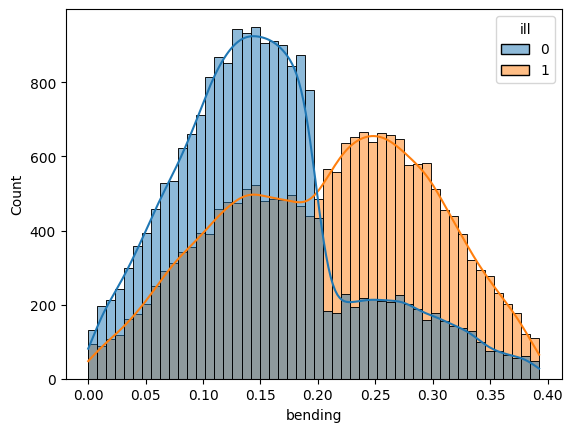

In [9]:
sns.histplot(data=df, x='bending', hue='ill', kde=True)

<Axes: xlabel='main_spherical', ylabel='Count'>

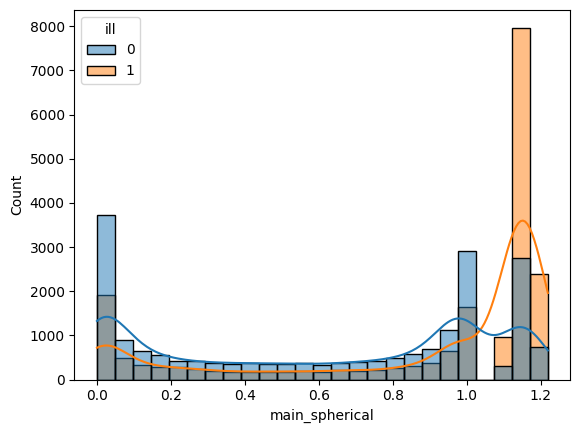

In [10]:
sns.histplot(data=df, x='main_spherical', hue='ill', kde=True)

<Axes: xlabel='sec_spherical', ylabel='Count'>

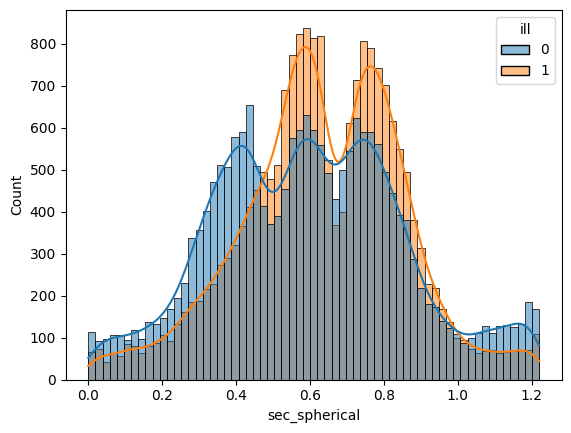

In [11]:
sns.histplot(data=df, x='sec_spherical', hue='ill', kde=True)

<Axes: xlabel='sphere_diff', ylabel='Count'>

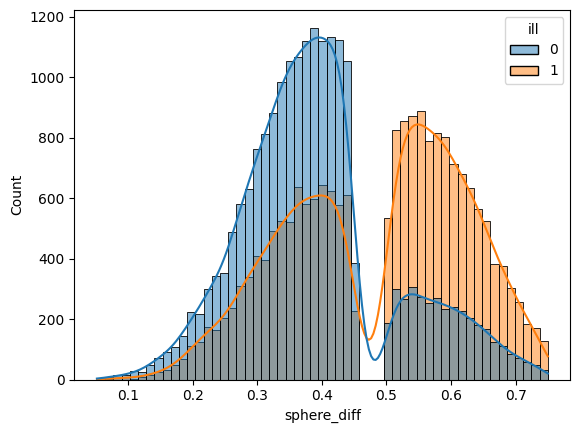

In [12]:
sns.histplot(data=df, x='sphere_diff', hue='ill', kde=True)

<Axes: xlabel='arm_position', ylabel='Density'>

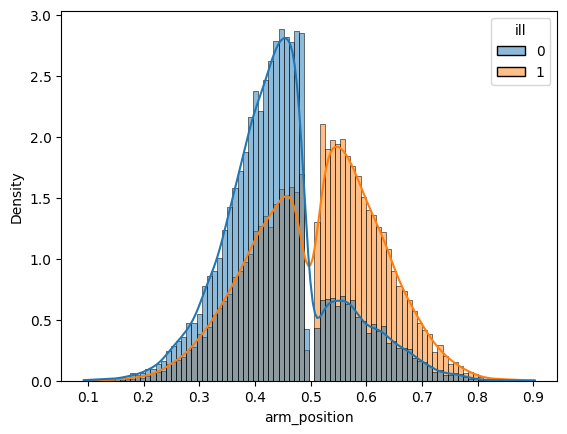

In [13]:
sns.histplot(data=df, x='arm_position', hue='ill', kde=True, stat='density')

In [14]:
def load_imgs(paths):
  imgs = []
  for path in paths:
      img = Image.open(path).convert('RGB')
      imgs.append(img)
  return imgs

In [15]:
notill_samples = df[df.ill == 0].sample(6)
paths = notill_samples.filename.apply(lambda x: data_dir / dataset / x)
notill_imgs = load_imgs(paths)
ill_samples = df[df.ill == 1].sample(6)
paths = ill_samples.filename.apply(lambda x: data_dir / dataset / x)
ill_imgs = load_imgs(paths)

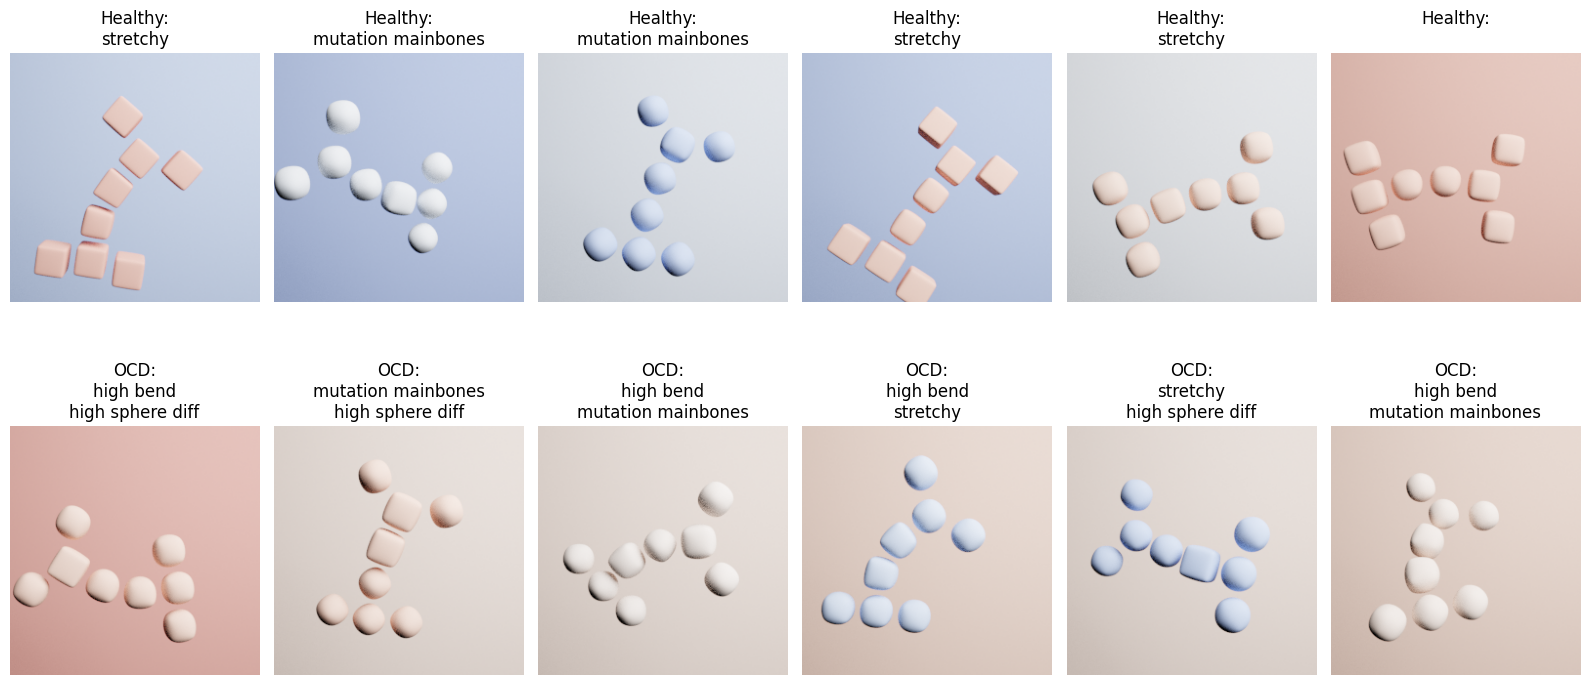

In [16]:
axes = plt.subplots(2, 6, figsize=(16, 8))[1]
for i, img in enumerate(notill_imgs):
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    chars = [c.replace('_', ' ') for c in notill_samples.iloc[i].ill_chars]
    chars = '\n'.join(chars)
    axes[0, i].set_title(f'Healthy:\n{chars}')
for i, img in enumerate(ill_imgs):
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    chars = [c.replace('_', ' ') for c in ill_samples.iloc[i].ill_chars]
    chars = '\n'.join(chars)
    axes[1, i].set_title(f'OCD:\n{chars}')
plt.tight_layout()
plt.show()

In [17]:
ill_samples.iloc[3]

obj_name                                                            ocd
num_ill_chars                                                         2
ill_chars                                         [high_bend, stretchy]
labeling_error                                                    False
main_spherical                                                 0.903175
sec_spherical                                                  0.664318
sec_bones                                                            11
bending                                                        0.272069
obj_rotation_roll                                              0.006277
obj_rotation_pitch                                             0.046013
obj_rotation_yaw                                              -2.079442
fliplr                                                            False
position_x                                                    -0.540939
position_y                                                     -

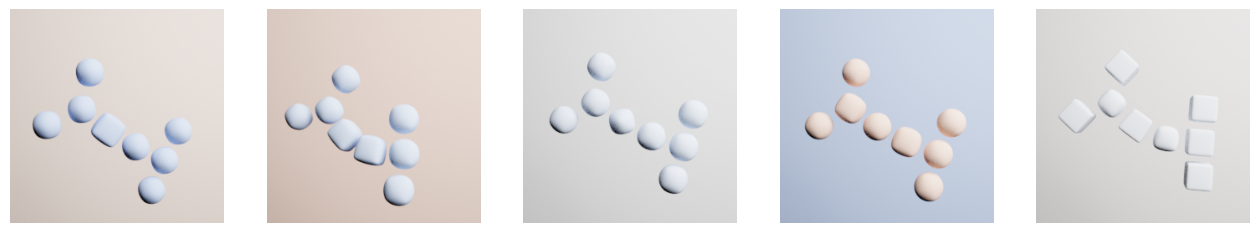

In [18]:
samples = df.sample(5)
paths = samples.filename.apply(lambda x: data_dir / dataset / x)
imgs = load_imgs(paths)

axes = plt.subplots(1, 5, figsize=(16, 4))[1]
for i, img in enumerate(imgs):
    axes[i].imshow(img)
    axes[i].axis('off')

In [ ]:
pred = [1, 1, 0, 0, 1]

ill = samples.ill_chars.values
pred = [f'{p} ({i})' for p, i in zip(pred, ill)]
pred

["1 (['mutation_mainbones', 'high_sphere_diff', 'stretchy'])",
 "1 (['high_bend'])",
 '0 ([])',
 "0 (['stretchy'])",
 "1 (['stretchy', 'high_sphere_diff', 'high_bend'])"]